In [1]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from langdetect import detect, DetectorFactory

DetectorFactory.seed = 0 # for consistency

In [2]:
df = pd.read_csv('data/amazon_bestsellers_reviews.csv')
df.dtypes # helpful_votes should be int, date should be datetime64
df.head()

,department,product_index,product_name,product_url,reviewer,rating,date,verified,title,body,helpful_votes,variant,image_count
0,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Sridhar Mani,5,"Reviewed in the United States on March 17, 2026",Verified Purchase,Best-in-Class Quality and Sound,These Apple EarPods with USB-C are truly best ...,28 people found this helpful,Size: One SizeStyle: USB-C,0
1,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,A.S,5,"Reviewed in the United States on April 11, 2026",Verified Purchase,Great Sound and Comfort,"I bought these for my son, who prefers traditi...",8 people found this helpful,Size: One SizeStyle: USB-C,0
2,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Amazon_Customer,5,"Reviewed in the United States on April 10, 2026",Verified Purchase,"The $9 Audiophile Secret: Small Dongle, Big Pr...",Let’s be honest: nobody actually wants to live...,7 people found this helpful,Size: One SizeStyle: USB-C,0
3,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,K,5,"Reviewed in the United States on March 17, 2026",Verified Purchase,better than overhead headphones,I honestly love these headphones so much. I ac...,23 people found this helpful,Size: One SizeStyle: USB-C,0
4,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Low,5,"Reviewed in the United States on April 25, 2026",Verified Purchase,Worth the extra money. They're the best ones I...,"Best you can buy. I have 4 usbc ear buds, thes...",NaN,Size: One SizeStyle: USB-C,0


In [3]:
# Split date into date and location, parse date
pattern = r'Reviewed in (.+?) on (.+)'
df[['location', 'date']] = df['date'].str.extract(pattern)
df['date'] = pd.to_datetime(df['date'])
df.head()

,department,product_index,product_name,product_url,reviewer,rating,date,verified,title,body,helpful_votes,variant,image_count,location
0,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Sridhar Mani,5,2026-03-17,Verified Purchase,Best-in-Class Quality and Sound,These Apple EarPods with USB-C are truly best ...,28 people found this helpful,Size: One SizeStyle: USB-C,0,the United States
1,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,A.S,5,2026-04-11,Verified Purchase,Great Sound and Comfort,"I bought these for my son, who prefers traditi...",8 people found this helpful,Size: One SizeStyle: USB-C,0,the United States
2,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Amazon_Customer,5,2026-04-10,Verified Purchase,"The $9 Audiophile Secret: Small Dongle, Big Pr...",Let’s be honest: nobody actually wants to live...,7 people found this helpful,Size: One SizeStyle: USB-C,0,the United States
3,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,K,5,2026-03-17,Verified Purchase,better than overhead headphones,I honestly love these headphones so much. I ac...,23 people found this helpful,Size: One SizeStyle: USB-C,0,the United States
4,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Low,5,2026-04-25,Verified Purchase,Worth the extra money. They're the best ones I...,"Best you can buy. I have 4 usbc ear buds, thes...",NaN,Size: One SizeStyle: USB-C,0,the United States


In [4]:
# Clean helpful_votes and create target column
pattern = r'(One|\d+)'
df['helpful_votes'] = df['helpful_votes'].str.extract(pattern)[0]
df['helpful_votes'] = df['helpful_votes'].replace('One', 1)
df['helpful_votes'] = pd.to_numeric(df['helpful_votes'], errors='coerce').fillna(0).astype(int)
df['is_helpful'] = (df['helpful_votes'] > 0).astype(int) # Assign 1 or 0
df.head()

,department,product_index,product_name,product_url,reviewer,rating,date,verified,title,body,helpful_votes,variant,image_count,location,is_helpful
0,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Sridhar Mani,5,2026-03-17,Verified Purchase,Best-in-Class Quality and Sound,These Apple EarPods with USB-C are truly best ...,28,Size: One SizeStyle: USB-C,0,the United States,1
1,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,A.S,5,2026-04-11,Verified Purchase,Great Sound and Comfort,"I bought these for my son, who prefers traditi...",8,Size: One SizeStyle: USB-C,0,the United States,1
2,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Amazon_Customer,5,2026-04-10,Verified Purchase,"The $9 Audiophile Secret: Small Dongle, Big Pr...",Let’s be honest: nobody actually wants to live...,7,Size: One SizeStyle: USB-C,0,the United States,1
3,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,K,5,2026-03-17,Verified Purchase,better than overhead headphones,I honestly love these headphones so much. I ac...,23,Size: One SizeStyle: USB-C,0,the United States,1
4,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Low,5,2026-04-25,Verified Purchase,Worth the extra money. They're the best ones I...,"Best you can buy. I have 4 usbc ear buds, thes...",0,Size: One SizeStyle: USB-C,0,the United States,0


In [5]:
# Text Preprocessing (Title + Body)

# Remove emojis and non-ascii characters
df['title'] = df['title'].str.encode('ascii', 'ignore').str.decode('ascii')
df['body'] = df['body'].str.encode('ascii', 'ignore').str.decode('ascii')

# Filter non-english reviews
def is_english(text):
    try:
        return detect(str(text)) == 'en'
    except:
        return False

df = df[df['body'].apply(is_english)].copy()


# Preparing Text for LSA
df['text_for_lsa'] = df['title'].fillna('') + ' ' + df['body'].fillna('')
df['text_for_lsa'] = df['text_for_lsa'].str.lower()
df['text_for_lsa'] = df['text_for_lsa'].str.replace(f"[{re.escape(string.punctuation)}]", " ", regex=True)
df['text_for_lsa'] = df['text_for_lsa'].str.replace(r'\d+', '', regex=True)

# Removing Stopwords
def remove_stopwords(text):
    words = [word for word in text.split() if word not in ENGLISH_STOP_WORDS]
    return ' '.join(words)

df['text_for_lsa'] = df['text_for_lsa'].apply(remove_stopwords)
df['text_for_lsa'] = df['text_for_lsa'].str.strip().str.replace(r'\s+', ' ', regex=True)

df.head()

,department,product_index,product_name,product_url,reviewer,rating,date,verified,title,body,helpful_votes,variant,image_count,location,is_helpful,text_for_lsa
0,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Sridhar Mani,5,2026-03-17,Verified Purchase,Best-in-Class Quality and Sound,These Apple EarPods with USB-C are truly best ...,28,Size: One SizeStyle: USB-C,0,the United States,1,best class quality sound apple earpods usb c t...
1,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,A.S,5,2026-04-11,Verified Purchase,Great Sound and Comfort,"I bought these for my son, who prefers traditi...",8,Size: One SizeStyle: USB-C,0,the United States,1,great sound comfort bought son prefers traditi...
2,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Amazon_Customer,5,2026-04-10,Verified Purchase,"The $9 Audiophile Secret: Small Dongle, Big Pr...",Lets be honest: nobody actually wants to live ...,7,Size: One SizeStyle: USB-C,0,the United States,1,audiophile secret small dongle big practicalit...
3,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,K,5,2026-03-17,Verified Purchase,better than overhead headphones,I honestly love these headphones so much. I ac...,23,Size: One SizeStyle: USB-C,0,the United States,1,better overhead headphones honestly love headp...
4,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Low,5,2026-04-25,Verified Purchase,Worth the extra money. They're the best ones I...,"Best you can buy. I have 4 usbc ear buds, thes...",0,Size: One SizeStyle: USB-C,0,the United States,0,worth extra money best ones best buy usbc ear ...


In [6]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(token_pattern=r'\w+', min_df=5)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['text_for_lsa'])

In [7]:
# 5. LSA (Latent Semantic Analysis) via TruncatedSVD
svd = TruncatedSVD(n_components=100, random_state=42)
svd_ng = svd.fit(tfidf_matrix)
lsa_features = svd_ng.fit_transform(tfidf_matrix)

In [8]:
energy_ng = (svd_ng.singular_values_)**2
energy_ratio_ng = energy_ng / energy_ng.sum()

In [9]:
"""Utility functions for SVD and LSA notebook""" # UTILS

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms


def plot_energy_ratio(energy_ratio, tol=0.90):
    """Return energy ratio plot given energy ratio

    Parameters
    ----------
    energy_ratio : numpy array
        Array containing the percentage of energy preserved by
        each of the singular vectors.

    tol : float, default=0.90
        Default tolerance value for the optimal threshold

    Returns
    -------
    fig, ax : matplotlib figure and axes
        Figure and axes of the plot
    """
    # Get cumsum of energy ratio
    energy_ratio = (energy_ratio).cumsum()

    # Get index where energy ratio exceeds tolerance
    thresh = np.min(np.arange(len(energy_ratio))[energy_ratio >= tol]) + 1

    # Initialize figure
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111)

    # Plot explained varianced
    ax.plot(range(0, len(energy_ratio) + 1), [0] + energy_ratio.tolist(),
            lw=3.0, marker='o')

    # Plot threshold line
    ax.axvline(thresh, linestyle='-', lw=2.5, color='tab:orange')
    
    # Annotate threshold
    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(1.05*thresh, 0.05, f"Number of SVs: {int(thresh)}",
            color='tab:orange', weight='bold', fontsize=12, transform=trans)

    # Set ylim
    ax.set_ylim([min(energy_ratio), 1.05])
    ax.set_xlim([0., len(energy_ratio)])

    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Set axis labels
    ax.set_xlabel('Number of SVs', fontsize=12)
    ax.set_ylabel('Cumulative Energy Preserved', fontsize=12)
    fig.suptitle('Cumulative Energy Preserved versus Number of SVs',
                 fontsize=14, weight='bold')

    # Set axis limits
    ax.set_ylim(0, 1)
    
    return fig, ax, thresh


def plot_reconstruction_error(reconstruction_error, tol=1e-2):
    """Return energy ratio plot given energy ratio

    Parameters
    ----------
    reconstruction_error : numpy array
        Array containing the reconstruction error.

    tol : float, default=1e-2
        Default tolerance value for the optimal threshold

    Returns
    -------
    fig, ax : matplotlib figure and axes
        Figure and axes of the plot
    """
    # Get index where energy ratio exceeds tolerance
    thresh = np.min(np.arange(len(reconstruction_error))[reconstruction_error <= tol]) + 1

    # Initialize figure
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111)

    # Plot explained varianced
    ax.plot(range(0, len(reconstruction_error) + 1), [None] + reconstruction_error.tolist(),
            lw=3.0, marker='o')

    # Plot threshold line
    ax.axvline(thresh, linestyle='-', lw=2.5, color='tab:orange')
    
    # Annotate threshold
    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(1.05*thresh, 0.05, f"Number of SVs: {int(thresh)}",
            color='tab:orange', weight='bold', fontsize=12, transform=trans)

    # Set ylim
    ax.set_xlim([0., len(reconstruction_error)])

    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Set axis labels
    ax.set_xlabel('Number of SVs', fontsize=12)
    ax.set_ylabel('Reconstruction Error', fontsize=12)
    fig.suptitle('Reconstruction Error versus Number of SVs',
                 fontsize=14, weight='bold')
    
    return fig, ax, thresh


def plot_principal_components(X_transformed, W, column_1, column_2, margin=0.05,
                 hue=None, vals=None, figsize=(16, 8), wspace=0.03,
                 palette='default'):
    """
    Plot the principal components given X_transformed, W

    Parameters
    ----------
    X_transformed : pandas Data Frame
        Data Frame containing the tranformed feature vectors

    W : pandas Data Frame
        The data frame containing the principle components

    column_1, column 2 : str
        Principal component columns to be inspected

    margin : float, default=0.05
        Text margin on subplot 2 for prettification

    hue : numpy array, default=None
        Discriminator array to use as hue

    vals : list, default=None
        Specify to focus on specific hue values for pair plot.

    figsize : tuple, default=(16, 5)
        Specify the figure size of the lsa analysis plot

    wspace : float, default=0.03
        Specify the horizontal space between subplots

    palette : list of rgb, default='default'
        palette to use for plotting

    Returns
    -------
    fig, axes : matplotlib Figure and Axes
        Figure and axes of the PC analysis
    """
    # Set color palette
    if palette == 'default':
        palette = sns.color_palette('tab10')

    # Initialize figure
    fig, axes = plt.subplots(1, 2, figsize=figsize,
                             gridspec_kw={'wspace': wspace})

    # Set vals if not specified
    if vals is None:
        if hue is not None:
            vals = set(hue)

    # Plot word scatter plot for first 2 W's
    if hue is not None:
        for i, val in enumerate(vals):
            axes[0].plot(X_transformed.loc[hue == val, column_1],
                         X_transformed.loc[hue == val, column_2], 'o',
                         color=palette[i],
                         label=val)
        axes[0].legend()
    else:
        axes[0].plot(X_transformed.loc[:, column_1], X_transformed.loc[:, column_2], 'o')

    # Set axis labels
    axes[0].set_xlabel(column_1, fontsize=12)
    axes[0].set_ylabel(column_2, fontsize=12)

    # Remove spines
    for spine in ['top', 'right']:
        axes[0].spines[spine].set_visible(False)

    # Get lsas
    W = W.T
    lsas = np.append(W.loc[:, [column_1]],
                     W.loc[:, [column_2]],
                     axis=1)

    # Compute for weights, rank, then get indices
    weights = np.linalg.norm(lsas, axis=1)
    indices = weights.argsort()[-20:]

    # Get features
    features = W.index

    # Iterate through all top features
    for feature, vec in zip(features[indices], lsas[indices]):
        # Draw vector representation
        axes[1].annotate('', xy=(vec[0], vec[1]),  xycoords='data',
                         xytext=(0, 0), textcoords='data',
                         arrowprops=dict(facecolor=palette[0],
                                         edgecolor='none'))

        # Draw corresponding feature
        axes[1].text(vec[0], vec[1], feature, ha='center', color=palette[1],
                     fontsize=12, weight='bold', zorder=10)

        # Adjust xlim and ylim
        xlim = [np.min(W.loc[:, column_1]),
                np.max(W.loc[:, column_1])]
        xlim_range = xlim[1] - xlim[0]
        ylim = [np.min(W.loc[:, column_2]),
                np.max(W.loc[:, column_2])]
        ylim_range = ylim[1] - ylim[0]
        axes[1].set_xlim(xlim[0] - xlim_range*margin,
                         xlim[1] + xlim_range*margin)
        axes[1].set_ylim(ylim[0] - ylim_range*margin,
                         ylim[1] + ylim_range*margin)

        # Off axis for the vector plot
        axes[1].tick_params(axis='both',which='both',top=False, bottom=False,
                            labelbottom=False, labelleft=False, left=False)

    # Set axis labels
    axes[1].set_xlabel(column_1, fontsize=12)
    axes[1].set_ylabel(column_2, fontsize=12)

    # Remove spines
    for spine in ['top', 'right', 'left', 'bottom']:
        axes[1].spines[spine].set_visible(False)

    return fig, axes


def plot_topic_vector(term_topic_matrix, column, num_terms=20):
    """Return a plot of the weights of the topic vector with largest
    magnitude"""
    fig, ax = plt.subplots(figsize=(8, 6))
    (term_topic_matrix.loc[
        term_topic_matrix[column].abs().nlargest(num_terms).index[::-1], column
        ]
                      .plot(kind='barh'))

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel("Weight", fontsize=12)
    ax.set_ylabel("Term", fontsize=12)

    fig.suptitle(column, fontsize=14, weight='bold')
    
    return fig, ax

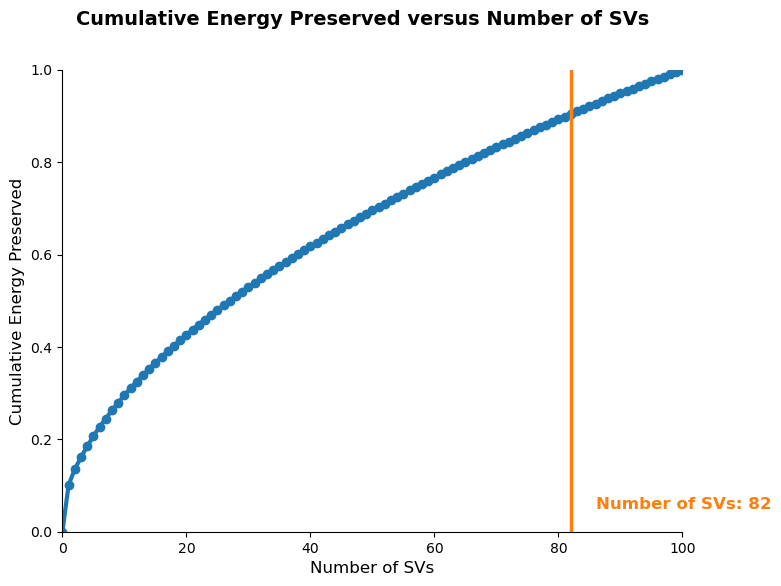

In [10]:
fig, ax, thresh = plot_energy_ratio(energy_ratio_ng);

In [11]:
truncated_lsa = lsa_features[:, :thresh]
truncated_lsa

array([[ 0.26190978, -0.09198203,  0.21445817, ...,  0.07560281,
        -0.04543813, -0.02475438],
       [ 0.21421637,  0.02569493,  0.1253311 , ..., -0.04028961,
        -0.078987  ,  0.00930942],
       [ 0.2196005 , -0.07190919,  0.06339242, ...,  0.04615711,
         0.02526989, -0.03628995],
       ...,
       [ 0.14307139, -0.02383619,  0.03047827, ..., -0.02996989,
         0.00557544, -0.03164422],
       [ 0.18176668, -0.29760933, -0.08386434, ...,  0.09332858,
         0.04379449,  0.10837068],
       [ 0.0762707 ,  0.04833825,  0.02138473, ..., -0.03750766,
        -0.04583037, -0.09380394]], shape=(1517, 82))

In [12]:
# Clustering semantic features
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(truncated_lsa)
df['cluster'] = clusters
df.head()

c:\Users\rafas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


,department,product_index,product_name,product_url,reviewer,rating,date,verified,title,body,helpful_votes,variant,image_count,location,is_helpful,text_for_lsa,cluster
0,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Sridhar Mani,5,2026-03-17,Verified Purchase,Best-in-Class Quality and Sound,These Apple EarPods with USB-C are truly best ...,28,Size: One SizeStyle: USB-C,0,the United States,1,best class quality sound apple earpods usb c t...,1
1,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,A.S,5,2026-04-11,Verified Purchase,Great Sound and Comfort,"I bought these for my son, who prefers traditi...",8,Size: One SizeStyle: USB-C,0,the United States,1,great sound comfort bought son prefers traditi...,1
2,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Amazon_Customer,5,2026-04-10,Verified Purchase,"The $9 Audiophile Secret: Small Dongle, Big Pr...",Lets be honest: nobody actually wants to live ...,7,Size: One SizeStyle: USB-C,0,the United States,1,audiophile secret small dongle big practicalit...,1
3,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,K,5,2026-03-17,Verified Purchase,better than overhead headphones,I honestly love these headphones so much. I ac...,23,Size: One SizeStyle: USB-C,0,the United States,1,better overhead headphones honestly love headp...,1
4,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Low,5,2026-04-25,Verified Purchase,Worth the extra money. They're the best ones I...,"Best you can buy. I have 4 usbc ear buds, thes...",0,Size: One SizeStyle: USB-C,0,the United States,0,worth extra money best ones best buy usbc ear ...,1


In [13]:
# Export
df.to_csv("data/amazon_bestsellers_reviews_cleaned_clustered.csv", index=False)